# **S&P 500 Forecasting with XGBoost**

XGBoost model predicts each stock's next-day log return, then converts the
prediction back into a next-day closing price.

workflow is designed to:

* prevent features and targets from leaking across ticker symbols
* preserve chronological ordering during model selection and evaluation
* compare the model against a strong naive baseline
* use ticker identity as a categorical feature
* tune the model only on validation data and evaluate the test set once

In [1]:
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Seed used to make model training and random operations reproducible
RANDOM_STATE = 42
# File path for the source S&P 500 stock datase
DATA_PATH = Path("/kaggle/input/datasets/camnugent/sandp500/all_stocks_5yr.csv")
# Output path for the trained XGBoost model
MODEL_PATH = Path("sp500_xgboost_model.json")
# Output path for test-set predictions
PREDICTIONS_PATH = Path("sp500_xgboost_test_predictions.csv")
# Chronological dataset split proportions
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15
# Number of trading periods ahead to predict
# A value of 1 represents the next available trading day
PREDICTION_HORIZON = 1

# Set random seed for reproducible results
np.random.seed(RANDOM_STATE)
# let pandas to display up to 100 columns when inspecting DataFrames
pd.set_option("display.max_columns", 100)
# format floating-point values with commas and six decimal places
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.2.0


## Load and Validate the Data

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

required_columns = {"date", "open", "high", "low", "close", "volume", "Name"}

df = pd.read_csv(DATA_PATH)
missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

numeric_columns = ["open", "high", "low", "close", "volume"]

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")
df["Name"] = df["Name"].astype("string")

df = (
    df.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["date", "Name", *numeric_columns])
    .drop_duplicates(subset=["Name", "date"], keep="last")
    .query("open > 0 and high > 0 and low > 0 and close > 0 and volume >= 0")
    .sort_values(["Name", "date"])
    .reset_index(drop=True)
)

print(df.info())
print(df.head())
print(f"Rows: {len(df):,}")
print(f"Tickers: {df['Name'].nunique():,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619029 entries, 0 to 619028
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619029 non-null  datetime64[ns]
 1   open    619029 non-null  float64       
 2   high    619029 non-null  float64       
 3   low     619029 non-null  float64       
 4   close   619029 non-null  float64       
 5   volume  619029 non-null  int64         
 6   Name    619029 non-null  string        
dtypes: datetime64[ns](1), float64(4), int64(1), string(1)
memory usage: 33.1 MB
None
        date      open      high       low     close   volume Name
0 2013-02-08 45.070000 45.350000 45.000000 45.080000  1824755    A
1 2013-02-11 45.170000 45.180000 44.450000 44.600000  2915405    A
2 2013-02-12 44.810000 44.950000 44.500000 44.620000  2373731    A
3 2013-02-13 44.810000 45.240000 44.680000 44.750000  2052338    A
4 2013-02-14 44.720000 44.780000 44.360000 44.580000  3826245   

## Feature Engineering
- all rolling, lagged, exponential, and target calculations are performed
independently within each ticker
- this prevents the final observation for one company from being used to create a feature or target for another company

In [3]:
def calculate_rsi(series: pd.Series, window: int = 14) -> pd.Series:
    """Calculate Wilder-style RSI for one chronologically ordered price series."""
    delta = series.diff()
    gains = delta.clip(lower=0.0)
    losses = -delta.clip(upper=0.0)

    average_gain = gains.ewm(
        alpha=1 / window,
        min_periods=window,
        adjust=False,
    ).mean()
    average_loss = losses.ewm(
        alpha=1 / window,
        min_periods=window,
        adjust=False,
    ).mean()

    relative_strength = average_gain / average_loss.replace(0.0, np.nan)
    rsi = 100.0 - (100.0 / (1.0 + relative_strength))

    # handle windows containing only gains or only losses.
    rsi = rsi.mask((average_loss == 0.0) & (average_gain > 0.0), 100.0)
    rsi = rsi.mask((average_gain == 0.0) & (average_loss > 0.0), 0.0)
    return rsi


def add_features(data: pd.DataFrame) -> pd.DataFrame:
    """Create end-of-day features and a one-step-ahead target per ticker."""
    result = data.copy()
    ticker = result.groupby("Name", sort=False)

    # Price and volume transformations
    result["previous_close"] = ticker["close"].shift(1)
    result["log_return_1d"] = np.log(result["close"] / result["previous_close"])
    result["gap_return"] = np.log(result["open"] / result["previous_close"])
    result["intraday_return"] = np.log(result["close"] / result["open"])
    result["high_low_range_pct"] = (result["high"] - result["low"]) / result["close"]
    result["close_position_in_range"] = (
        (result["close"] - result["low"])
        / (result["high"] - result["low"]).replace(0.0, np.nan)
    )
    result["log_volume"] = np.log1p(result["volume"])
    result["volume_change_1d"] = ticker["volume"].pct_change(fill_method=None)

    # lagged returns contain only information known by the current close
    for lag in [1, 2, 3, 5, 10, 20]:
        result[f"return_lag_{lag}"] = result.groupby("Name", sort=False)[
            "log_return_1d"
        ].shift(lag)

    # rolling trend, momentum, volatility, and volume features
    for window in [5, 10, 20, 50]:
        rolling_close = ticker["close"].transform(
            lambda series: series.rolling(window, min_periods=window).mean()
        )
        rolling_return = result.groupby("Name", sort=False)["log_return_1d"].transform(
            lambda series: series.rolling(window, min_periods=window)
            .mean()
        )
        rolling_volatility = result.groupby("Name", sort=False)[
            "log_return_1d"
        ].transform(
            lambda series: series.rolling(window, min_periods=window).std()
        )
        rolling_volume = ticker["volume"].transform(
            lambda series: series.rolling(window, min_periods=window).mean()
        )

        result[f"close_to_ma_{window}"] = result["close"] / rolling_close - 1.0
        result[f"return_mean_{window}"] = rolling_return
        result[f"volatility_{window}"] = rolling_volatility
        result[f"volume_to_ma_{window}"] = (
            result["volume"] / rolling_volume.replace(0.0, np.nan)
        )

    # RSI, MACD, Bollinger Bands, and rolling VWAP
    result["rsi_14"] = ticker["close"].transform(calculate_rsi)
    result["ema_12"] = ticker["close"].transform(
        lambda series: series.ewm(span=12, adjust=False).mean()
    )
    result["ema_26"] = ticker["close"].transform(
        lambda series: series.ewm(span=26, adjust=False).mean()
    )
    result["macd_pct"] = (result["ema_12"] - result["ema_26"]) / result["close"]
    result["macd_signal_pct"] = result.groupby("Name", sort=False)[
        "macd_pct"
    ].transform(lambda series: series.ewm(span=9, adjust=False).mean())

    ma_20 = ticker["close"].transform(
        lambda series: series.rolling(20, min_periods=20).mean()
    )
    std_20 = ticker["close"].transform(
        lambda series: series.rolling(20, min_periods=20).std()
    )
    upper_band = ma_20 + 2.0 * std_20
    lower_band = ma_20 - 2.0 * std_20

    result["bollinger_position"] = (
        (result["close"] - lower_band)
        / (upper_band - lower_band).replace(0.0, np.nan)
    )
    result["bollinger_width"] = (upper_band - lower_band) / ma_20

    typical_price = (result["high"] + result["low"] + result["close"]) / 3.0
    result["price_volume"] = typical_price * result["volume"]

    rolling_price_volume = result.groupby("Name", sort=False)[
        "price_volume"
    ].transform(lambda series: series.rolling(20, min_periods=20).sum())
    rolling_volume_sum = ticker["volume"].transform(
        lambda series: series.rolling(20, min_periods=20).sum()
    )
    rolling_vwap_20 = rolling_price_volume / rolling_volume_sum.replace(0.0, np.nan)
    result["close_to_vwap_20"] = result["close"] / rolling_vwap_20 - 1.0

    # Calendar features use cyclic encodings instead of treating dates as linear values
    day_of_week = result["date"].dt.dayofweek
    month = result["date"].dt.month

    result["day_of_week_sin"] = np.sin(2.0 * np.pi * day_of_week / 5.0)
    result["day_of_week_cos"] = np.cos(2.0 * np.pi * day_of_week / 5.0)
    result["month_sin"] = np.sin(2.0 * np.pi * month / 12.0)
    result["month_cos"] = np.cos(2.0 * np.pi * month / 12.0)

    # equal-weight market context calculated from all stocks observed on the same day
    result["market_return_1d"] = result.groupby("date")["log_return_1d"].transform(
        "mean"
    )
    result["market_dispersion_1d"] = result.groupby("date")[
        "log_return_1d"
    ].transform("std")
    result["market_breadth"] = (result["log_return_1d"] > 0.0).groupby(
        result["date"]
    ).transform("mean")
    result["relative_return_1d"] = (
        result["log_return_1d"] - result["market_return_1d"]
    )
    result["return_percentile"] = result.groupby("date")["log_return_1d"].rank(
        method="average",
        pct=True,
    )
    result["volume_change_percentile"] = result.groupby("date")[
        "volume_change_1d"
    ].rank(method="average", pct=True)

    # predict the next observed close for the same ticker
    result["target_date"] = ticker["date"].shift(-PREDICTION_HORIZON)
    result["next_close"] = ticker["close"].shift(-PREDICTION_HORIZON)
    result["target_log_return"] = np.log(result["next_close"] / result["close"])

    return result


df = add_features(df)
df = df.replace([np.inf, -np.inf], np.nan)

## Select Features

- XGBoost is tree-based, so standardization is unnecessary. 

- Keeping `Name` as a categorical feature lets one pooled model learn ticker-specific behavior without creating hundreds of manual one-hot columns.

In [4]:
FEATURES = [
    "Name",
    "open",
    "high",
    "low",
    "close",
    "log_volume",
    "log_return_1d",
    "gap_return",
    "intraday_return",
    "high_low_range_pct",
    "close_position_in_range",
    "volume_change_1d",
    "return_lag_1",
    "return_lag_2",
    "return_lag_3",
    "return_lag_5",
    "return_lag_10",
    "return_lag_20",
    "close_to_ma_5",
    "close_to_ma_10",
    "close_to_ma_20",
    "close_to_ma_50",
    "return_mean_5",
    "return_mean_10",
    "return_mean_20",
    "return_mean_50",
    "volatility_5",
    "volatility_10",
    "volatility_20",
    "volatility_50",
    "volume_to_ma_5",
    "volume_to_ma_10",
    "volume_to_ma_20",
    "volume_to_ma_50",
    "rsi_14",
    "macd_pct",
    "macd_signal_pct",
    "bollinger_position",
    "bollinger_width",
    "close_to_vwap_20",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
    "market_return_1d",
    "market_dispersion_1d",
    "market_breadth",
    "relative_return_1d",
    "return_percentile",
    "volume_change_percentile",
]

model_df = (
    df.dropna(subset=[*FEATURES, "target_date", "target_log_return", "next_close"])
    .sort_values(["date", "Name"])
    .reset_index(drop=True)
)

# establish one shared category mapping before slicing the data
ticker_categories = sorted(model_df["Name"].unique().tolist())
model_df["Name"] = pd.Categorical(
    model_df["Name"],
    categories=ticker_categories,
)

print(f"Usable modeling rows: {len(model_df):,}")
print(f"Features: {len(FEATURES)}")

Usable modeling rows: 593,281
Features: 50


## Chronological Train, Validation, and Test Split
the split is based on unique dates, not row positions. boundary observations
whose target falls in the next partition are purged to prevent label leakage.

In [5]:
if not np.isclose(TRAIN_FRACTION + VALIDATION_FRACTION + TEST_FRACTION, 1.0):
    raise ValueError("Train, validation, and test fractions must sum to 1.0.")

unique_dates = np.sort(model_df["date"].unique())
minimum_dates = 100

if len(unique_dates) < minimum_dates:
    raise ValueError(
        f"At least {minimum_dates} unique dates are required; found {len(unique_dates)}."
    )

train_end_index = int(len(unique_dates) * TRAIN_FRACTION) - 1
validation_end_index = int(
    len(unique_dates) * (TRAIN_FRACTION + VALIDATION_FRACTION)
) - 1

train_end_date = pd.Timestamp(unique_dates[train_end_index])
validation_end_date = pd.Timestamp(unique_dates[validation_end_index])

train_mask = model_df["target_date"] <= train_end_date
validation_mask = (
    (model_df["date"] > train_end_date)
    & (model_df["target_date"] <= validation_end_date)
)
test_mask = model_df["date"] > validation_end_date

train_df = model_df.loc[train_mask].copy()
validation_df = model_df.loc[validation_mask].copy()
test_df = model_df.loc[test_mask].copy()

if min(len(train_df), len(validation_df), len(test_df)) == 0:
    raise ValueError("At least one chronological partition is empty.")

X_train = train_df[FEATURES]
y_train = train_df["target_log_return"]

X_validation = validation_df[FEATURES]
y_validation = validation_df["target_log_return"]

X_test = test_df[FEATURES]
y_test = test_df["target_log_return"]

print(
    "Train:",
    train_df["date"].min().date(),
    "to",
    train_df["target_date"].max().date(),
    X_train.shape,
)
print(
    "Validation:",
    validation_df["date"].min().date(),
    "to",
    validation_df["target_date"].max().date(),
    X_validation.shape,
)
print(
    "Test:",
    test_df["date"].min().date(),
    "to",
    test_df["target_date"].max().date(),
    X_test.shape,
)

# limit extreme model outputs using thresholds learned only from training targets
return_clip_lower = float(y_train.quantile(0.001))
return_clip_upper = float(y_train.quantile(0.999))

Train: 2013-04-23 to 2016-08-26 (411136, 50)
Validation: 2016-08-29 to 2017-05-17 (89734, 50)
Test: 2017-05-18 to 2018-02-07 (91414, 50)


## Evaluation Utilities (reusable functions)

In [6]:
def returns_to_close(
    current_close: pd.Series | np.ndarray,
    predicted_log_return: pd.Series | np.ndarray,
) -> np.ndarray:
    """Convert predicted log returns into next-day close predictions."""
    predicted_log_return = np.asarray(predicted_log_return, dtype=float)
    predicted_log_return = np.clip(
        predicted_log_return,
        return_clip_lower,
        return_clip_upper,
    )
    return np.asarray(current_close, dtype=float) * np.exp(predicted_log_return)


def regression_metrics(
    actual_close: pd.Series | np.ndarray,
    predicted_close: pd.Series | np.ndarray,
    current_close: pd.Series | np.ndarray,
) -> dict[str, float]:
    """Return price-level and directional forecasting metrics."""
    actual_close = np.asarray(actual_close, dtype=float)
    predicted_close = np.asarray(predicted_close, dtype=float)
    current_close = np.asarray(current_close, dtype=float)

    rmse = float(np.sqrt(mean_squared_error(actual_close, predicted_close)))
    mae = float(mean_absolute_error(actual_close, predicted_close))
    mape = float(
        np.mean(np.abs((actual_close - predicted_close) / actual_close)) * 100.0
    )
    r2 = float(r2_score(actual_close, predicted_close))

    actual_direction = np.sign(actual_close - current_close)
    predicted_direction = np.sign(predicted_close - current_close)
    directional_accuracy = float(
        np.mean(actual_direction == predicted_direction) * 100.0
    )

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_pct": mape,
        "R2": r2,
        "Directional_accuracy_pct": directional_accuracy,
    }


def print_metrics(label: str, metrics: dict[str, float]) -> None:
    print(f"\n{label}")
    for metric_name, metric_value in metrics.items():
        print(f"  {metric_name}: {metric_value:,.6f}")

## Hyperparameter Search on the Validation Period

- small, targeted search is used instead of shuffled or ordinary K-fold cross-
validation. 

- every candidate trains on the past and is scored on a later period.

In [7]:
# XGBoost params
BASE_PARAMETERS: dict[str, Any] = {
    "objective": "reg:squarederror",  # minimize squared error for a continuous regression target
    "eval_metric": "rmse",  # measure validation performance using RMSE (root mean squared error)
    "tree_method": "hist",  # use histogram-based tree construction for faster training
    "enable_categorical": True,  # let XGBoost to process pandas categorical features
    "learning_rate": 0.025,  # control how much each new tree contributes to the ensemble
    "n_estimators": 2_500,  # set the maximum number of boosting trees before early stopping
    "early_stopping_rounds": 100,  # stop when validation RMSE does not improve for 100 rounds
    "max_bin": 256,  # set the maximum number of histogram bins used for continuous features
    "max_cat_to_onehot": 4,  # one-hot encode categorical features with no more than four categories
    "random_state": RANDOM_STATE,  # make randomized training operations reproducible
    "n_jobs": -1,  # use all available CPU cores during model training
    "verbosity": 0,  # suppress XGBoost training messages and warnings
}

# candidate specific params tested during validation
PARAMETER_CANDIDATES = [
    {
        "max_depth": 4,  # limit each tree to four levels to reduce model complexity
        "min_child_weight": 10,  # require sufficient training weight before creating a child node
        "subsample": 0.85,  # train each tree using a random 85% of the training rows
        "colsample_bytree": 0.85,  # allow each tree to use a random 85% of the features
        "reg_alpha": 0.05,  # apply light L1 regularization to leaf weights
        "reg_lambda": 8.0,  # apply L2 regularization to reduce large leaf weights
        "gamma": 0.00,  # allow a split whenever it produces any positive loss reduction
    },
    {
        "max_depth": 5,  # allow moderately deeper trees and more feature interactions
        "min_child_weight": 5,  # permit splits containing fewer observations than Candidate 1
        "subsample": 0.90,  # train each tree using a random 90% of the training rows
        "colsample_bytree": 0.90,  # allow each tree to use a random 90% of the features
        "reg_alpha": 0.10,  # apply slightly stronger L1 regularization
        "reg_lambda": 10.0,  # apply stronger L2 regularization
        "gamma": 0.00,  # doesn't require a minimum loss reduction beyond zero
    },
    {
        "max_depth": 6,  # allow deeper trees to capture more complex relationships
        "min_child_weight": 12,  # require larger child nodes to control overfitting
        "subsample": 0.80,  # train each tree using a random 80% of the training rows
        "colsample_bytree": 0.80,  # allow each tree to use a random 80% of the features
        "reg_alpha": 0.20,  # apply stronger L1 regularization to simplify leaf weights
        "reg_lambda": 15.0,  # apply stronger L2 regularization to stabilize predictions
        "gamma": 0.01,  # require a small improvement before accepting a new split
    },
    {
        "max_depth": 7,  # allow the deepest trees among the tested candidates
        "min_child_weight": 20,  # require large child nodes to offset the deeper tree structure
        "subsample": 0.75,  # train each tree using a random 75% of the training rows
        "colsample_bytree": 0.90,  # allow each tree to use a random 90% of the features
        "reg_alpha": 0.30,  # apply the strongest tested L1 regularization
        "reg_lambda": 20.0,  # apply the strongest tested L2 regularization
        "gamma": 0.02,  # require the largest tested loss reduction before creating a split
    },
]

# store the validation metrics and settings for every candidate
search_results: list[dict[str, Any]] = []

# store the candidate model with the lowest validation RMSE
best_model: xgb.XGBRegressor | None = None

# store the candidate-specific params of the best model
best_parameters: dict[str, Any] | None = None

# initialize best validation RMSE to infinity so the first valid model replaces it
best_validation_rmse = np.inf

# store the number of trees selected by early stopping for the best model
best_n_estimators = 0

# train and evaluate each candidate configuration
for candidate_number, candidate_parameters in enumerate(
    PARAMETER_CANDIDATES,
    start=1,
):
    # combine the shared settings with the current candidate-specific settings
    model_parameters = {**BASE_PARAMETERS, **candidate_parameters}

    # create an XGBoost regressor using the combined parameter set
    candidate_model = xgb.XGBRegressor(**model_parameters)

    # train on historical training data and monitor the later validation period
    candidate_model.fit(
        X_train,
        y_train,
        eval_set=[(X_validation, y_validation)],  # data used for early stopping
        verbose=False,  # prevent per-tree evaluation results from being printed
    )

    # predict next-day log returns for the validation observations
    validation_return_prediction = candidate_model.predict(X_validation)

    # convert predicted log returns into predicted next-day closing prices
    validation_close_prediction = returns_to_close(
        validation_df["close"],
        validation_return_prediction,
    )

    # calculate price-error and directional metrics on the validation period
    validation_metrics = regression_metrics(
        validation_df["next_close"],
        validation_close_prediction,
        validation_df["close"],
    )

    # convert the zero-based best iteration into the actual number of fitted trees
    candidate_n_estimators = int(candidate_model.best_iteration) + 1

    # save the candidate settings, selected tree count, and validation metrics
    search_results.append(
        {
            "candidate": candidate_number,
            "best_n_estimators": candidate_n_estimators,
            **candidate_parameters,
            **validation_metrics,
        }
    )

    # list out a summary of the current candidate's validation result
    print(
        f"Candidate {candidate_number}: "
        f"validation RMSE={validation_metrics['RMSE']:.6f}, "
        f"trees={candidate_n_estimators}"
    )

    # replace the current best model when this candidate has a lower validation RMSE
    if validation_metrics["RMSE"] < best_validation_rmse:
        best_validation_rmse = validation_metrics["RMSE"]
        best_model = candidate_model
        best_parameters = candidate_parameters.copy()
        best_n_estimators = candidate_n_estimators

# stop execution if no candidate completed successfully
if best_model is None or best_parameters is None:
    raise RuntimeError("Hyperparameter search did not produce a valid model.")

# convert all candidate results into a table and rank them by validation RMSE
search_results_df = pd.DataFrame(search_results).sort_values("RMSE")

# the full ranked validation results
print("\nValidation search results:")
print(search_results_df)

# the candidate-specific settings selected by validation RMSE
print("\nBest parameters:")
print(best_parameters)

# the number of trees selected through early stopping
print(f"Best number of trees: {best_n_estimators}")

Candidate 1: validation RMSE=1.826214, trees=29
Candidate 2: validation RMSE=1.827405, trees=32
Candidate 3: validation RMSE=1.825591, trees=19
Candidate 4: validation RMSE=1.824855, trees=18

Validation search results:
   candidate  best_n_estimators  max_depth  min_child_weight  subsample  \
3          4                 18          7                20   0.750000   
2          3                 19          6                12   0.800000   
0          1                 29          4                10   0.850000   
1          2                 32          5                 5   0.900000   

   colsample_bytree  reg_alpha  reg_lambda    gamma     RMSE      MAE  \
3          0.900000   0.300000   20.000000 0.020000 1.824855 0.835194   
2          0.800000   0.200000   15.000000 0.010000 1.825591 0.835946   
0          0.850000   0.050000    8.000000 0.000000 1.826214 0.835498   
1          0.900000   0.100000   10.000000 0.000000 1.827405 0.835757   

   MAPE_pct       R2  Directional_accu

## Retrain on Train + Validation Data
selected tree count is fixed before the test period is touched. final
model is then fitted on all pre-test observations.

In [8]:
X_train_validation = pd.concat([X_train, X_validation], axis=0)
y_train_validation = pd.concat([y_train, y_validation], axis=0)

FINAL_PARAMETERS = {
    **BASE_PARAMETERS,
    **best_parameters,
    "n_estimators": best_n_estimators,
}
FINAL_PARAMETERS.pop("early_stopping_rounds", None)

final_model = xgb.XGBRegressor(**FINAL_PARAMETERS)
final_model.fit(X_train_validation, y_train_validation, verbose=False)
final_model.save_model(MODEL_PATH)

print(f"Saved model to: {MODEL_PATH.resolve()}")

Saved model to: /kaggle/working/sp500_xgboost_model.json


## Test-Set Evaluation

In [9]:
test_return_prediction = final_model.predict(X_test)
test_close_prediction = returns_to_close(
    test_df["close"],
    test_return_prediction,
)

# strong one-day baseline predicts that tomorrow's close equals today's close
naive_close_prediction = test_df["close"].to_numpy()

model_test_metrics = regression_metrics(
    test_df["next_close"],
    test_close_prediction,
    test_df["close"],
)
naive_test_metrics = regression_metrics(
    test_df["next_close"],
    naive_close_prediction,
    test_df["close"],
)

print_metrics("XGBoost test metrics", model_test_metrics)
print_metrics("Naive baseline test metrics", naive_test_metrics)

rmse_improvement_pct = (
    (naive_test_metrics["RMSE"] - model_test_metrics["RMSE"])
    / naive_test_metrics["RMSE"]
    * 100.0
)
mae_improvement_pct = (
    (naive_test_metrics["MAE"] - model_test_metrics["MAE"])
    / naive_test_metrics["MAE"]
    * 100.0
)

print(f"\nRMSE improvement over baseline: {rmse_improvement_pct:.3f}%")
print(f"MAE improvement over baseline: {mae_improvement_pct:.3f}%")


XGBoost test metrics
  RMSE: 2.397596
  MAE: 0.962062
  MAPE_pct: 0.977524
  R2: 0.999663
  Directional_accuracy_pct: 52.193318

Naive baseline test metrics
  RMSE: 2.391807
  MAE: 0.961159
  MAPE_pct: 0.976963
  R2: 0.999664
  Directional_accuracy_pct: 0.831383

RMSE improvement over baseline: -0.242%
MAE improvement over baseline: -0.094%


## Save Predictions

In [10]:
predictions = test_df[["date", "target_date", "Name", "close", "next_close"]].copy()
predictions = predictions.rename(
    columns={
        "close": "current_close",
        "next_close": "actual_next_close",
    }
)
predictions["predicted_log_return"] = test_return_prediction
predictions["predicted_next_close"] = test_close_prediction
predictions["naive_next_close"] = naive_close_prediction
predictions["absolute_error"] = np.abs(
    predictions["actual_next_close"] - predictions["predicted_next_close"]
)
predictions["naive_absolute_error"] = np.abs(
    predictions["actual_next_close"] - predictions["naive_next_close"]
)

predictions.to_csv(PREDICTIONS_PATH, index=False)
print(f"Saved predictions to: {PREDICTIONS_PATH.resolve()}")
print(predictions.head())

Saved predictions to: /kaggle/working/sp500_xgboost_test_predictions.csv
             date target_date  Name  current_close  actual_next_close  \
501867 2017-05-18  2017-05-19     A      55.850000          56.130000   
501868 2017-05-18  2017-05-19   AAL      44.650000          45.220000   
501869 2017-05-18  2017-05-19   AAP     148.510000         151.470000   
501870 2017-05-18  2017-05-19  AAPL     152.540000         153.060000   
501871 2017-05-18  2017-05-19  ABBV      65.630000          65.580000   

        predicted_log_return  predicted_next_close  naive_next_close  \
501867              0.000100             55.855585         55.850000   
501868              0.000100             44.654465         44.650000   
501869              0.000100            148.524851        148.510000   
501870              0.000100            152.555254        152.540000   
501871              0.000100             65.636563         65.630000   

        absolute_error  naive_absolute_error  
501867  

## Feature Importance

day_of_week_sin           0.085871
return_lag_10             0.078631
market_return_1d          0.067772
market_breadth            0.057210
gap_return                0.051555
close_position_in_range   0.047701
market_dispersion_1d      0.044158
month_cos                 0.043324
intraday_return           0.040950
month_sin                 0.037860
return_lag_2              0.037098
return_mean_5             0.031361
volatility_20             0.029651
return_lag_1              0.029498
high_low_range_pct        0.028257
close_to_ma_10            0.026678
return_mean_10            0.023338
return_lag_3              0.022503
volatility_10             0.022082
day_of_week_cos           0.021688
Name: importance, dtype: float32


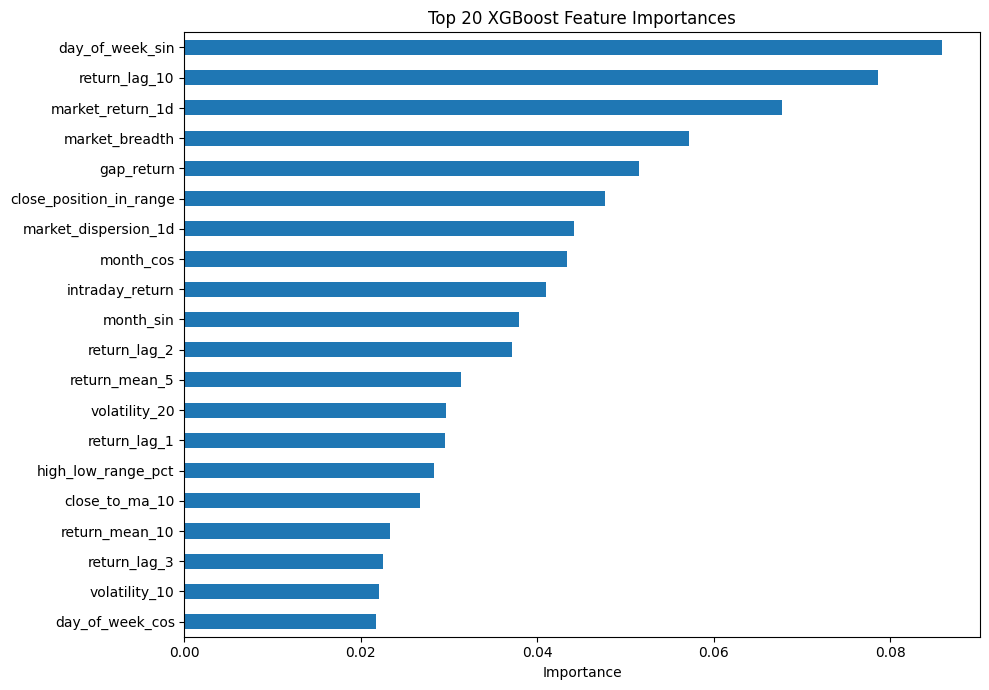

In [11]:
feature_importance = (
    pd.Series(final_model.feature_importances_, index=FEATURES, name="importance")
    .sort_values(ascending=False)
    .head(20)
)

print(feature_importance)

plt.figure(figsize=(10, 7))
feature_importance.sort_values().plot(kind="barh")
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()